# XGBoost and SHAP Analysis
In this notebook, we will examine another ensemble approach based on "boosting", called XGBoost. Then, we will use a "SHAP" analysis to look under the hood of the model and see how it is making its predictions.

**Learning Objectives**

By the end of this notebook, you should be able to:
1. Implement an optimized random forest regression model using XGBoost
2. Use a SHAP analysis to determine which model features are important for making predictions.

**Import modules**

Begin by importing the modules to be used in this notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In this notebook, we will use two new modules for XGBoost and SHAP analyses:

In [2]:
import xgboost as xgb
import shap

### The Sea Otter Regression Problem Revisited

In this notebook, we will revisit the sea otter data from the Random Forest regression notebook. Let's read that in and prepare it as before:

In [3]:
df = pd.read_csv('../data/mock_otter_weekly_data.csv')

In [4]:
df['Location Index']=0
df.loc[df['Location']=='Elkhorn Slough', "Location Index"] = 1
df['Season Index']=0
df.loc[df['Season']=='Spring', "Season Index"] = 1
df.loc[df['Season']=='Summer', "Season Index"] = 2
df.loc[df['Season']=='Fall', "Season Index"] = 3
df['Tide Index']=0
df.loc[df['Tide']=='High', "Tide Index"] = 1
df['Weather Index']=0
df.loc[df['Weather']=='Windy', "Weather Index"] = 1
df.loc[df['Weather']=='Sunny', "Weather Index"] = 2
df.loc[df['Weather']=='Cloudy', "Weather Index"] = 3

## XGBoost

In our previous example, we used an ensemble of decision trees - a random forest - to create a regression model that predicted sea otter raft sizes based on the data above. This gave us some improved results over a single decision tree, but there is still some room for improvement. In the random forest approach, a random "bootstrap" sample is taken from the training data for each decision tree. Then, this decision tree is fit to the data (maximizing information gain) independently of any other tree. At the end, the predictions from the trees are averaged to yield the final prediction.

In the **XGBoost** algorithm (described [HERE](https://doi.org/10.48550/arXiv.1603.02754)), decision trees are not trained independently, but each successive tree is used to improve upon the errors from previous trees. This process of updating a collection of different models sequentially is known as gradient *boosting*. It differs from the process of training each one independently, which we called bagging. 

As applied to this example, we can think of this process in symbols as follows: we have a modeled prediction of otter raft size $\hat{y}_i^{(t)}$ for the $i$th set of environmental variables $x_i$ in tree $t$. A new tree ($t+1$) is then trained to make corrections $f$ to update the prediction:

$$
\hat{y}_i^{(t+1)} = \hat{y}_i^{(t)} + f(x_i)
$$


The tree structure is chosen using split criteria (based on information gain), while the boosting framework minimizes a global loss function using gradient-based updates. In the gradient descent algorithm, there is also a learning rate applied to $f$ and a regularization term to penalize large weights (to be discussed in a subsequent notebook), but for now, let's take a look at the implementation.

### Implementing an XGBoost Regressor

As we have done for previous models, let's prep our design matrix and our target data:

In [5]:
X = np.column_stack([df['Location Index'], df['Season Index'],
                     df['Tide Index'], df['Weather Index'], df['CanopyCover']])
y = df['OtterCount']

and split our data into a training set and testing set:

In [6]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

Just like our `scikit-learn` models, we can make an XGBoost model with the built-in class and then fit it to our training data:

In [7]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=51
)
model.fit(X_train, y_train);

Let's see how our model is performing on both the training set and the testing set:

In [8]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

Let's see what these results look like:

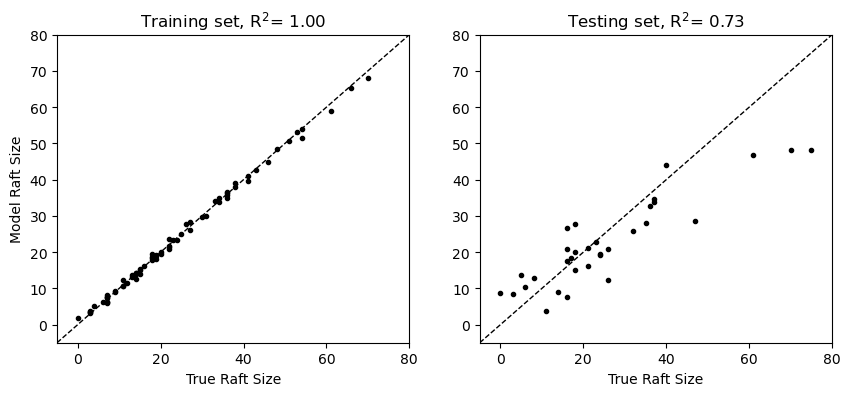

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.ylabel('Model Raft Size')
plt.xlabel('True Raft Size')
plt.title(f"Training set, R$^2$= {r2_score(y_train, y_pred_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.xlabel('True Raft Size')
plt.title(f"Testing set, R$^2$= {r2_score(y_test, y_pred_test):.2f}");

In these results, we see that XGBoost yields more robust predictions on the test set relative to the random forest explored in the previous notebook.

## SHAP Analysis

In the section above, we can see *what* our XGBoost model predicts and how well these predictions match our training and testing data, but we don't get much insight for *how* these predictions are made. This is important because a central motivation for studying relationships between our input features (the environmental variables here) and the target features (the otter raft sizes) is to understand how much each variable affects the target. To understand this, we can compute Shapley values (named for Lloyd Shapley, who was working on a related problem in game theory, see [HERE](https://doi.org/10.1515/9781400881970-018)). When used to understand a model with these values, this approach is typically called a SHAP (SHapley Additive exPlanations) analysis. 

Shapley values $\phi_n(x)$ are computed for each input feature $n$, such that the model prediction $f(x)$ is composed of the sum of each value, i.e. 

$$
f(x)= \phi_0 +\sum_{n=1}^N\phi_n(x)
$$

where $\phi_0$ is a baseline prediction. In other words, SHAP values exactly decompose the prediction into additive feature contributions.

In the context of the sea otter problem, $\phi_0$ is the baseline number of otters that are found in a given raft (the mean across all model predictions) and $N=5$ corresponds to the input features for location, season, tide, weather, and canopy cover (the columns of the design matrix). 

Let's take a look at an example for our XGBoost model:

In [10]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test) 
shap_values.feature_names = ["Location", "Season", "Tide", "Weather", "CanopyCover"]

The `shap_values` object above has different attributes used in the model explanation. For example, we can take a look at the baseline value as follows:

In [11]:
shap_values.base_values[0]

np.float64(23.552710655857975)

Similarly, the Shapley values are stored in a `values` matrix - one for each set of input features. As a result, this matrix has the same shape as the design matrix:

In [12]:
print(np.shape(shap_values.values))
print(np.shape(X_test))

(32, 5)
(32, 5)


As a concrete example for what these individual values mean, let's take a look at one example prediction for our model. The first test set example has the following values for location, season, etc:

In [13]:
print(X_test[:1,:])

[[0.         2.         0.         2.         0.47762846]]


For these values, the model predicts the following raft size:

In [14]:
model.predict(X_test[:1,:])

array([46.809395], dtype=float32)

To see how each of these values contributed to the prediction, we can take a look at the Shapley values:

In [15]:
print(shap_values.values[:1,:])

[[ 9.52852742  8.18422332  1.65853798  5.03212021 -1.14672753]]


Here, we see that the location (Monterey Bay) contributed most positively to the prediction, followed by season (summer). This aligns with the plot in the previous notebook showing higher values in both Monterey Bay and in summer. Since the analysis of an individual feature is often of interest, this is built into the `shap` package as a plotting routine for visualization:

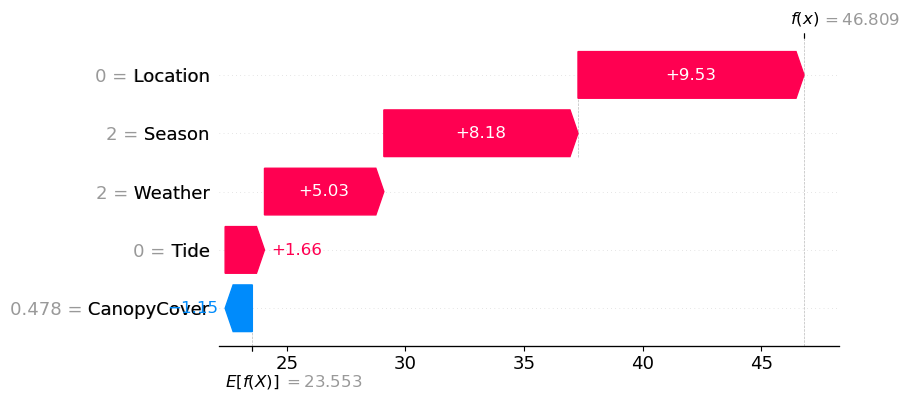

In [16]:
shap.plots.waterfall(shap_values[0])

We can check that these values reproduce the model prediction following the formula above:

In [17]:
shap_values.base_values[0] + np.sum(shap_values.values[:1,:])

np.float64(46.80939205581225)

In this example, we are taking a look at one prediction. However, we are often interested in how our values contribute overall to our predictions. To compute an overall importance of each feature, one option is to compute the mean of the absolute values of each set of Shapley values, i.e.

In [18]:
np.mean(np.abs(shap_values.values), axis=0)

array([7.59136602, 4.33771005, 1.42530724, 2.35578839, 3.07936374])

This is a common calculation and is also built into a plotting function in the `shap` package:

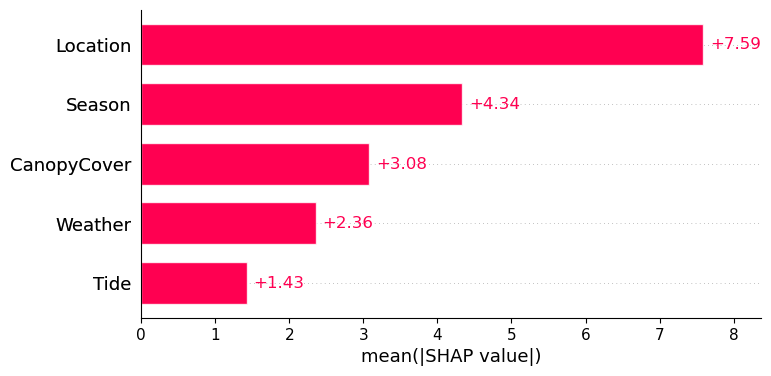

In [19]:
shap.plots.bar(shap_values)

Here, we see that across all predictions, location contributes most significantly to overall raft size.

**Key Takeaways**

1. The XGBoost algorithm creates a gradient boosted ensemble of decision trees, where each tree is trained sequentially to improve the errors of the previous trees.
2. A SHAP analysis can be used to assess a model *a posteriori* to determine which input features are most important for the model's predictions. 